# Quick Inference — STGCN Exact (ablebody2_exact)

Config: `configs/stgcn/ablebody2_exact/j.py` · Checkpoint: `work_dirs/stgcn/ablebody2_exact/joint/epoch_16.pth`

Loops over train/val/test and reports MAE / MSE / MRE / Pearson r / R² per split.

Note: `GCNHead` needs `test_cfg=dict(average_clips='score')` in the config or predictions collapse to a constant (already patched in `j.py`).

In [1]:
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from mmcv import Config
from mmcv.runner import load_checkpoint
from pyskl.models import build_model
from pyskl.datasets import build_dataset, build_dataloader
from copy import deepcopy

/home/students/mmasabo1/miniconda3/envs/pyskl_310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/students/mmasabo1/miniconda3/envs/pyskl_310/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(


In [2]:
CONFIG     = 'configs/stgcn/ablebody2_exact/j.py'
CHECKPOINT = 'work_dirs/stgcn/ablebody2_exact/joint/epoch_16.pth'
SPLITS     = ['train', 'val', 'test']
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

cfg = Config.fromfile(CONFIG)
PKL_PATH = cfg.ann_file
print('config    :', CONFIG)
print('checkpoint:', CHECKPOINT)
print('ann_file  :', PKL_PATH)
print('test_cfg  :', cfg.model.get('test_cfg'))   # needs average_clips='score' or preds collapse


config    : configs/stgcn/ablebody2_exact/j.py
checkpoint: work_dirs/stgcn/ablebody2_exact/joint/epoch_16.pth
ann_file  : /home/students/mmasabo1/summer26Research/ablebody2_exact.pkl
test_cfg  : {'average_clips': 'score'}


In [3]:
with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

for s in SPLITS:
    ids = data['split'][s]
    print(f'{s:5s}: {len(ids)} clips')
print('keypoint shape:', data['annotations'][0]['keypoint'].shape)   # (M, T, V, C)
print('label sample  :', data['annotations'][0]['label'])


train: 4710 clips
val  : 582 clips
test : 582 clips
keypoint shape: (1, 299, 17, 2)
label sample  : 3.5034488163512667


In [4]:
def build_split_loader(split):
    ds_cfg = deepcopy(cfg.data.val)          # plain PoseDataset template (train is a RepeatDataset)
    ds_cfg['type']      = 'PoseDataset'
    ds_cfg['ann_file']  = PKL_PATH
    ds_cfg['split']     = split
    ds_cfg['test_mode'] = True
    dataset = build_dataset(ds_cfg, dict(test_mode=True))
    loader = build_dataloader(
        dataset,
        videos_per_gpu=4,
        workers_per_gpu=2,
        shuffle=False,
    )
    return dataset, loader


In [5]:
model = build_model(cfg.model)
load_checkpoint(model, CHECKPOINT, map_location='cpu')
model = model.to(DEVICE)
model.eval()
print('Model loaded on', DEVICE, '| test_cfg =', getattr(model, 'test_cfg', None))


load checkpoint from local path: work_dirs/stgcn/ablebody2_exact/joint/epoch_16.pth
Model loaded on cuda | test_cfg = {'average_clips': 'score'}


In [6]:
def run_inference(loader):
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            y = batch['label'].numpy().flatten()

            # PoseC3D uses 'imgs'; GCN models use 'keypoint'
            if 'imgs' in batch:
                x = batch['imgs'].to(DEVICE)
                out = model(x, return_loss=False)
            else:
                x = batch['keypoint'].to(DEVICE)
                kw = {}
                if 'demographics' in batch:
                    kw['demographics'] = batch['demographics'].to(DEVICE)
                out = model(x, return_loss=False, **kw)

            p = np.array(out).flatten()
            if len(p) > len(y):                       # average over clips if >1 per sample
                p = p.reshape(len(y), -1).mean(axis=1)

            preds.extend(p.tolist())
            labels.extend(y.tolist())
    return np.array(preds), np.array(labels)


def compute_metrics(preds, labels):
    err  = preds - labels
    mae  = np.mean(np.abs(err))
    mse  = np.mean(err ** 2)
    mre  = np.mean(np.abs(err) / np.abs(labels))          # mean relative error
    r    = np.corrcoef(preds, labels)[0, 1]               # Pearson r
    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((labels - labels.mean()) ** 2)
    r2   = 1.0 - ss_res / ss_tot
    return dict(MAE=mae, MSE=mse, MRE=mre, r=r, R2=r2)


In [7]:
results = {}
for split in SPLITS:
    dataset, loader = build_split_loader(split)
    preds, labels = run_inference(loader)
    m = compute_metrics(preds, labels)
    results[split] = dict(preds=preds, labels=labels, **m)
    print(f'[{split}] n={len(preds)}  pred range=({preds.min():.3f}, {preds.max():.3f})')

print()
print(f'{"split":6s} {"MAE":>9s} {"MSE":>9s} {"MRE":>9s} {"r":>9s} {"R2":>9s}')
for split in SPLITS:
    m = results[split]
    print(f'{split:6s} {m["MAE"]:9.4f} {m["MSE"]:9.4f} {m["MRE"]:9.4f} {m["r"]:9.4f} {m["R2"]:9.4f}')



DEBUG PoseDataset.__init__
ann_file: /home/students/mmasabo1/summer26Research/ablebody2_exact.pkl
split: train
valid_ratio parameter: None
box_thr parameter: None


2026-08-30 11:02:48,793 - pyskl - INFO - 4710 videos remain after valid thresholding



After super().__init__():
  len(self.video_infos): 4710
  First sample keys: ['frame_dir', 'label', 'img_shape', 'total_frames', 'num_person_raw', 'keypoint', 'keypoint_score', 'name', 'file_number', 'gait', 'modality', 'age', 'gender', 'height', 'weight', 'watts', 'energy_cal', 'nearest_ee_watts', 'exact_windowing_energy_watts', 'windowing_drop_avg_energy_watts', 'heart_rate', 'exact_windowing_hr', 'windowing_drop_avg_hr', 'vo2_per_kg', 'rer', 've_stpd', 'mets', 'vo2_stpd', 'vco2_stpd']
  First sample 'total_frames': 299

Before valid_ratio filtering:
  self.valid_ratio: None
  type(self.valid_ratio): <class 'NoneType'>
  len(self.video_infos): 4710
  Will filtering run? False
  ✓ Filtering is DISABLED (valid_ratio=None)

FINAL len(self.video_infos): 4710

[train] n=4710  pred range=(0.485, 13.871)

DEBUG PoseDataset.__init__
ann_file: /home/students/mmasabo1/summer26Research/ablebody2_exact.pkl
split: val
valid_ratio parameter: None
box_thr parameter: None


2026-08-30 11:02:54,811 - pyskl - INFO - 582 videos remain after valid thresholding



After super().__init__():
  len(self.video_infos): 582
  First sample keys: ['frame_dir', 'label', 'img_shape', 'total_frames', 'num_person_raw', 'keypoint', 'keypoint_score', 'name', 'file_number', 'gait', 'modality', 'age', 'gender', 'height', 'weight', 'watts', 'energy_cal', 'nearest_ee_watts', 'exact_windowing_energy_watts', 'windowing_drop_avg_energy_watts', 'heart_rate', 'exact_windowing_hr', 'windowing_drop_avg_hr', 'vo2_per_kg', 'rer', 've_stpd', 'mets', 'vo2_stpd', 'vco2_stpd']
  First sample 'total_frames': 299

Before valid_ratio filtering:
  self.valid_ratio: None
  type(self.valid_ratio): <class 'NoneType'>
  len(self.video_infos): 582
  Will filtering run? False
  ✓ Filtering is DISABLED (valid_ratio=None)

FINAL len(self.video_infos): 582

[val] n=582  pred range=(0.692, 13.242)

DEBUG PoseDataset.__init__
ann_file: /home/students/mmasabo1/summer26Research/ablebody2_exact.pkl
split: test
valid_ratio parameter: None
box_thr parameter: None


2026-08-30 11:02:55,900 - pyskl - INFO - 582 videos remain after valid thresholding



After super().__init__():
  len(self.video_infos): 582
  First sample keys: ['frame_dir', 'label', 'img_shape', 'total_frames', 'num_person_raw', 'keypoint', 'keypoint_score', 'name', 'file_number', 'gait', 'modality', 'age', 'gender', 'height', 'weight', 'watts', 'energy_cal', 'nearest_ee_watts', 'exact_windowing_energy_watts', 'windowing_drop_avg_energy_watts', 'heart_rate', 'exact_windowing_hr', 'windowing_drop_avg_hr', 'vo2_per_kg', 'rer', 've_stpd', 'mets', 'vo2_stpd', 'vco2_stpd']
  First sample 'total_frames': 299

Before valid_ratio filtering:
  self.valid_ratio: None
  type(self.valid_ratio): <class 'NoneType'>
  len(self.video_infos): 582
  Will filtering run? False
  ✓ Filtering is DISABLED (valid_ratio=None)

FINAL len(self.video_infos): 582

[test] n=582  pred range=(0.562, 13.157)

split        MAE       MSE       MRE         r        R2
train     0.8803    1.0679    0.2106    0.9332    0.5928
val       0.9150    1.2206    0.2126    0.9214    0.5290
test      0.8733    1

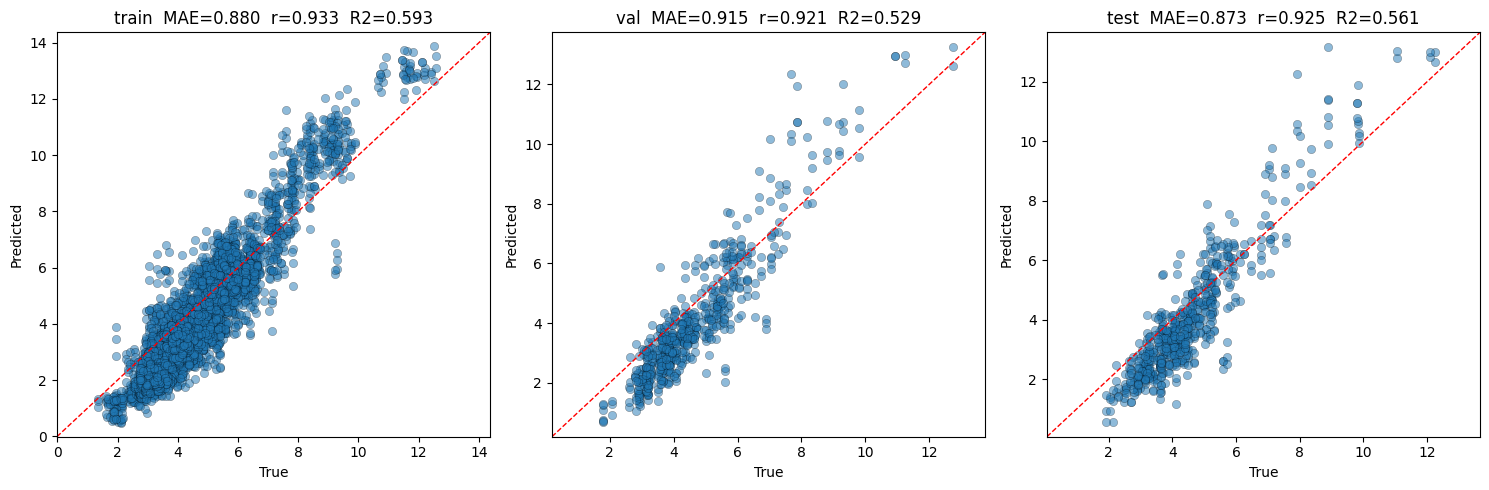

In [8]:
fig, axes = plt.subplots(1, len(SPLITS), figsize=(5 * len(SPLITS), 5))
for ax, split in zip(np.atleast_1d(axes), SPLITS):
    r = results[split]
    y, p = r['labels'], r['preds']
    ax.scatter(y, p, alpha=0.5, edgecolors='k', linewidths=0.3)
    lim = [min(y.min(), p.min()) - 0.5, max(y.max(), p.max()) + 0.5]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('True'); ax.set_ylabel('Predicted')
    ax.set_title(f'{split}  MAE={r["MAE"]:.3f}  r={r["r"]:.3f}  R2={r["R2"]:.3f}')
plt.tight_layout()
plt.show()
